In [1]:
#%matplotlib ipympl
%pylab notebook

Populating the interactive namespace from numpy and matplotlib


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#### Input Files

Add a string specifying the source in the `source` variable:
- `TESS` for TESS data
- `GaiaR` for red Gaia data
- `GaiaB` for blue Gaia data
- `GaiaG` for green Gaia data

In [7]:
###EDITABLE###
source = 'GaiaG'

In [8]:
if source == 'TESS':
    #TESS DATA - TESS
    model = pd.read_csv('model.out.3',delim_whitespace=True,comment='#', names = ['Phase','Magnitude'],usecols=[0,1])
    lcfit = pd.read_csv('lcfit.out.3',delim_whitespace=True,comment='#', names = ['Time','Magnitude','Error','Phase','Model','(O-C)Mag'])
elif source == 'GaiaR':
    #GAIA data - RED EPOCH
    model = pd.read_csv('model.red.gaia.out.3',delim_whitespace=True,comment='#', names = ['Phase','Magnitude_unscaled'],usecols=[0,1])
    lcfit = pd.read_csv('lcfit.red.gaia.out.3',delim_whitespace=True,comment='#', names = ['Time','Magnitude_unscaled','Error_unscaled','Phase','Model','(O-C)Mag'])
elif source == 'GaiaG':
    #GAIA data - GREEN EPOCH
    model = pd.read_csv('model.green.gaia.out.3',delim_whitespace=True,comment='#', names = ['Phase','Magnitude_unscaled'],usecols=[0,1])
    lcfit = pd.read_csv('lcfit.green.gaia.out.3',delim_whitespace=True,comment='#', names = ['Time','Magnitude_unscaled','Error_unscaled','Phase','Model','(O-C)Mag'])
elif source == 'GaiaB':
    #GAIA data - BLUE EPOCH
    model = pd.read_csv('model.blue.gaia.out.3',delim_whitespace=True,comment='#', names = ['Phase','Magnitude_unscaled'],usecols=[0,1])
    lcfit = pd.read_csv('lcfit.blue.gaia.out.3',delim_whitespace=True,comment='#', names = ['Time','Magnitude_unscaled','Error_unscaled','Phase','Model','(O-C)Mag'])
else:
    print('The source name is not inputted correctly. Please try again!')

# Normalise any Gaia data inputted 

if source == 'TESS':
    print('Finished!')
else:
    model_mag_max = model['Magnitude_unscaled'].min()
    model['Magnitude'] = model['Magnitude_unscaled']-model_mag_max

    lcfit['Magnitude'] = lcfit['Magnitude_unscaled']-model_mag_max

    print('Finished!')

Finished!


#### Convert Magnitude to Flux

In [9]:
#Calculating flux - TESS
model['Flux'] = 10**(model.Magnitude/-2.5)
lcfit['Flux'] = 10**(lcfit.Magnitude/-2.5)
lcfit['(O-C)'] = (10**(lcfit['(O-C)Mag']/-2.5))*model['Flux']-model['Flux']

#### Overplotting and Plotting Residuals

<IPython.core.display.Javascript object>


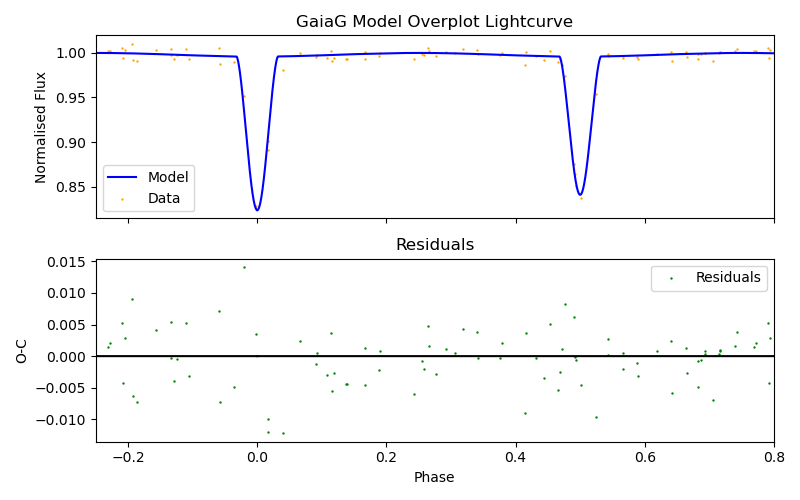

In [10]:
fig,ax = plt.subplots(nrows=2,sharex=True,figsize=(8,5))

zeros = [0]*len(model['Phase'])

ax[0].plot(model['Phase'],model['Flux'],c='b',label='Model')
ax[0].plot(model['Phase']-1,model['Flux'],c='b')

ax[0].scatter(lcfit['Phase'],lcfit['Flux'], color = 'orange',s=0.5,label='Data')
ax[0].scatter(lcfit['Phase']-1,lcfit['Flux'],color = 'orange',s=0.5)

ax[0].set_ylabel('Normalised Flux')

ax[0].set_title(str(source)+str(' Model Overplot Lightcurve'))

ax[1].plot(model['Phase'],zeros,c='k')
ax[1].plot(model['Phase']-1,zeros,c='k')

ax[1].scatter(lcfit.Phase,lcfit['(O-C)'],c='g',label='Residuals',s=0.5)
ax[1].scatter(lcfit.Phase-1,lcfit['(O-C)'],c='g',s=0.5)

ax[1].set_ylabel('O-C')

ax[1].set_title('Residuals')

ax[1].set_xlabel('Phase')
ax[1].set_xlim(-0.25,0.8)

ax[1].legend()
ax[0].legend()

fig.tight_layout()
fig.show()